# ORCA6 neutrino response 


## Requirements


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import uproot


## Folders and data

In [3]:
DATA_DIR  = Path.cwd()  
ROOT_FILE = DATA_DIR / 'ORCA6_433kt-y_opendata_v0.5.root'
BIN_FILE  = DATA_DIR / 'bins_433kt-y_v0.5.json'


## Read data

In [10]:
with BIN_FILE.open() as stream:
    bins = json.load(stream)

energy_edges   = np.asarray(bins['E_true_bins'])
costheta_edges = np.asarray(bins['cosT_true_bins'])

with uproot.open(ROOT_FILE) as root_file:
    response = root_file['binned_nu_response']
    arrays = response.arrays(
        ['E_reco_bin', 'Ct_reco_bin', 'E_reco_bin_center', 'Ct_reco_bin_center', 'Pdg', 'IsCC', 
         'E_true_bin', 'Ct_true_bin', 'E_true_bin_center', 'Ct_true_bin_center', 'W', 'WE', 'AnaClass'],
        library='np',
    )

print(f"Read {len(arrays['W']):,} filled response entries.")
print(f"True-space binning: {len(energy_edges) - 1} energy bins x "
      f"{len(costheta_edges) - 1} cos(theta) bins.")


Read 592,099 filled response entries.
True-space binning: 40 energy bins x 80 cos(theta) bins.


## True events

In [15]:
# Optional selections.  
# Examples: selected_pdg = 14; selected_is_cc = True; selected_ana_class = 1
selected_pdg       = None
selected_is_cc     = None
selected_ana_class = None

selection = np.ones(len(arrays['W']), dtype=bool)
if selected_pdg is not None:
    selection &= arrays['Pdg'] == selected_pdg
if selected_is_cc is not None:
    selection &= arrays['IsCC'] == selected_is_cc
if selected_ana_class is not None:
    selection &= arrays['AnaClass'] == selected_ana_class

histogram, _, _ = np.histogram2d(
    arrays['E_true_bin_center'][selection],
    arrays['Ct_true_bin_center'][selection],
    bins=(energy_edges, costheta_edges),
    #weights=arrays['W'][selection],
)

print(f"Selected entries: {selection.sum():,}")
print(f"Sum of W: {histogram.sum():.6g}")

Selected entries: 592,099
Sum of W: 592099


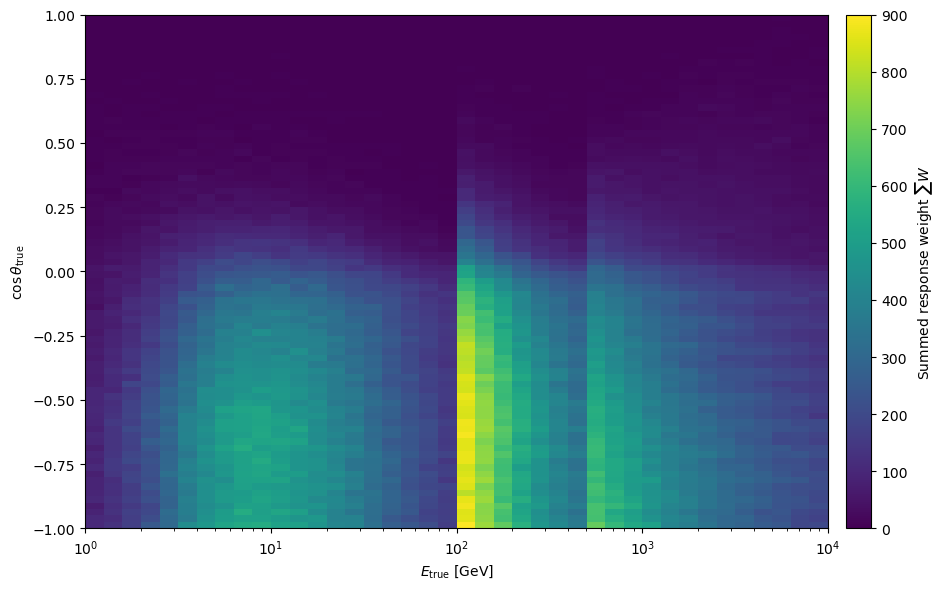

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.pcolormesh(
    energy_edges,
    costheta_edges,
    histogram.T,
    shading='auto',
    #norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
    cmap='viridis',
)
ax.set_xscale('log')
ax.set_xlabel(r'$E_{\rm true}$ [GeV]')
ax.set_ylabel(r'$\cos\theta_{\rm true}$')
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label(r'Summed response weight $\sum W$')
fig.tight_layout()
plt.show()